# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + standard scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

sns.set_style('whitegrid')

In [2]:
# Read in data, I decided to look at dropping missing on a feature by feature basis
df = pd.read_csv('hotels.csv')
# df=df.dropna()

---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [3]:
# Print out summary stats and basic info on the dataset, what trends do you notice?
df.dtypes
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [4]:
# Calculate prevalence of the target value, how hard of problem is this going to be?
counts = df['is_canceled'].value_counts()
print(counts)

# print out the percentage in the positive class, using a f string with 2 decimal places
positive_percentage = counts[1] / len(df) * 100
print(f'Percentage of positive class: {positive_percentage:.2f}%')

is_canceled
0    75166
1    44224
Name: count, dtype: int64
Percentage of positive class: 37.04%


37% seems very high, makes sense as to why we are looking to explore this data

---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [5]:
# Check for missing data and drop features with too many missing values, there are some. 
# df = pd.read_csv('hotels.csv') # re-reading data to make it easier to expriement with data
# Drop for too many missing values or too many categories
df= df.drop(['company', 'agent', 'country'], axis=1)


In [6]:
# Make data into categories if string or if numerical with large skews
df['babies'] = df['babies'].apply(lambda x: '0' if x == 0 else 'other').astype('category')
df['children'] = df['children'].apply(lambda x: '0' if x == 0 else 'other').astype('category')
df['adults'] = df['adults'].apply( lambda x: str(x) if x in [1, 2, 3] else 'other' ).astype('category')
df['hotel']=df['hotel'].astype('category')
df['arrival_date_month'] = df['arrival_date_month'].apply(
    lambda x: (
        'winter' if x in ['December', 'January', 'February'] else
        'spring' if x in ['March', 'April', 'May'] else
        'summer' if x in ['June', 'July', 'August'] else
        'fall'   if x in ['September', 'October', 'November'] else
        'other'
    )
).astype('category')
df['arrival_date_year']=df['arrival_date_year'].astype('category')
df['meal']=df['meal'].astype('category')
df['distribution_channel']=df['distribution_channel'].astype('category')
df['market_segment'] = df['market_segment'].apply(
    lambda x: x if x in [
        'Online TA', 'Offline TA/TO', 'Groups', 'Direct', 'Corporate'
    ] else 'other'
).astype('category')
df['is_repeated_guest']=df['is_repeated_guest'].astype('category')
df['previous_cancellations'] = df['previous_cancellations'].apply( lambda x: str(x) if x in [0, 1] else 'other' ).astype('category')
df['previous_bookings_not_canceled'] = df['previous_bookings_not_canceled'].apply(lambda x: '0' if x == 0 else 'other').astype('category')
df['reserved_room_type'] = df['reserved_room_type'].apply(
    lambda x: x if x in ['A', 'D', 'E'] else 'other'
).astype('category')
df['assigned_room_type'] = df['assigned_room_type'].apply(
    lambda x: x if x in ['A', 'D', 'E'] else 'other'
).astype('category')
df['booking_changes'] = df['booking_changes'].apply( lambda x: str(x) if x in [0,1, 2] else 'other' ).astype('category')

df['deposit_type']=df['deposit_type'].astype('category')
df['customer_type']=df['customer_type'].astype('category')
df['required_car_parking_spaces'] = df['required_car_parking_spaces'].apply( lambda x: str(x) if x in [0,1] else 'other' ).astype('category')
df['total_of_special_requests'] = df['total_of_special_requests'].apply( lambda x: str(x) if x in [0,1,2] else 'other' ).astype('category')


In [7]:
# Run value counts to pick which columns are grouped
# df['adults'].value_counts()
# df['previous_cancellations'].value_counts()
# df['previous_bookings_not_canceled'].value_counts()
# df['market_segment'].value_counts()
# df['reserved_room_type'].value_counts()
# df['assigned_room_type'].value_counts()
# df['booking_changes'].value_counts()

In [8]:
# There are two other features that need to be dropped because they  directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.
df= df.drop(['reservation_status', 'reservation_status_date'], axis=1)

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [9]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.
# df.dtypes
num_cols = [
    'lead_time',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'days_in_waiting_list',
    'adr'
]
cat_cols = [
    'hotel',
    'arrival_date_year',
    'arrival_date_month',
    'adults',
    'children',
    'babies',
    'meal',
    'market_segment',
    'distribution_channel',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'reserved_room_type',
    'assigned_room_type',
    'booking_changes',
    'deposit_type',
    'customer_type',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

X = df[cat_cols + num_cols]
y = df['is_canceled']

In [10]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

In [11]:
preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', MinMaxScaler(), num_cols) 
])

pipe_m1 = Pipeline(steps=[
    ('prep', preprocessor_m1),
    ('model', LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42))
])

---
 Model 1 Evaluation: Now that the model is build lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

In [12]:
pipe_m1.fit(X_train, y_train)

y_pred_m1 = pipe_m1.predict(X_test)

y_proba_m1 = pipe_m1.predict_proba(X_test)[:, 1]


In [13]:
# print(y_pred_m1)

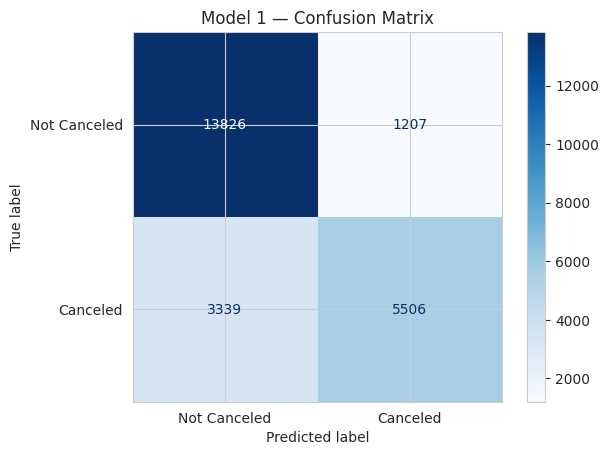

              precision    recall  f1-score   support

Not Canceled       0.81      0.92      0.86     15033
    Canceled       0.82      0.62      0.71      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.77      0.78     23878
weighted avg       0.81      0.81      0.80     23878



In [14]:
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Not Canceled', 'Canceled'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['Not Canceled', 'Canceled']))

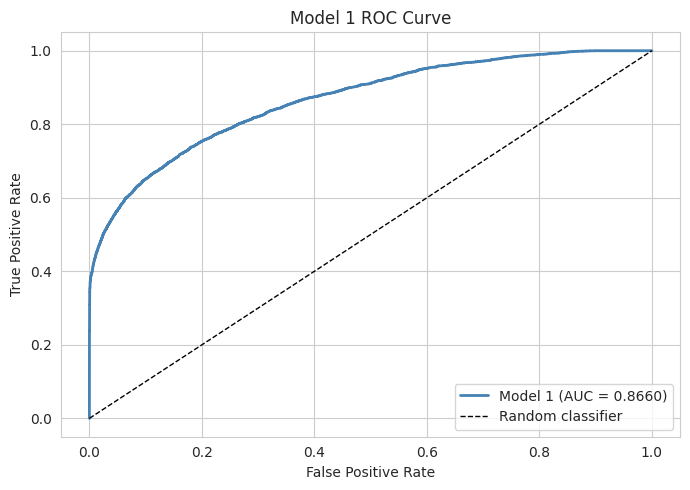

Model 1 ROC-AUC: 0.8660


In [15]:
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")

The goal of the assignment is to reduce false negatives, which our model does at a better rate than chance, which is a postiive. But, it is not incredible, and definitely could use work to improve

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



In [16]:
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', MinMaxScaler(), num_cols) 
])

pipe_m2 = Pipeline(steps=[
    ('prep', preprocessor_m2),
    ('model', LogisticRegression(solver='liblinear', max_iter=5000, random_state=42))
])

In [17]:
pipe_m2.fit(X_train, y_train)

y_pred_m2 = pipe_m2.predict(X_test)

y_proba_m2 = pipe_m2.predict_proba(X_test)[:, 1]


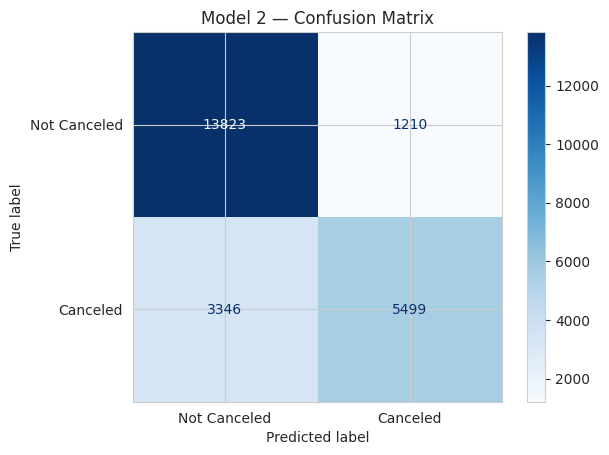

              precision    recall  f1-score   support

Not Canceled       0.81      0.92      0.86     15033
    Canceled       0.82      0.62      0.71      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.77      0.78     23878
weighted avg       0.81      0.81      0.80     23878



In [18]:
cm_m2 = confusion_matrix(y_test, y_pred_m2)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Not Canceled', 'Canceled'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_m2, target_names=['Not Canceled', 'Canceled']))

The new solvers improve the model slightly, but not to a significant impact

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

In [19]:
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', MinMaxScaler(), num_cols)
])

pipe_m3 = Pipeline(steps=[
    ('prep', preprocessor_m3),
    ('model', LogisticRegression(
        solver='liblinear',
        max_iter=5000,
        random_state=42,
        class_weight='balanced'
    ))
])

In [20]:
pipe_m3.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [24]:
# Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipe_m3, X_train, y_train, cv=cv, scoring='roc_auc')

y_pred_m3 = pipe_m3.predict(X_test)
y_proba_m3 = pipe_m3.predict_proba(X_test)[:, 1]


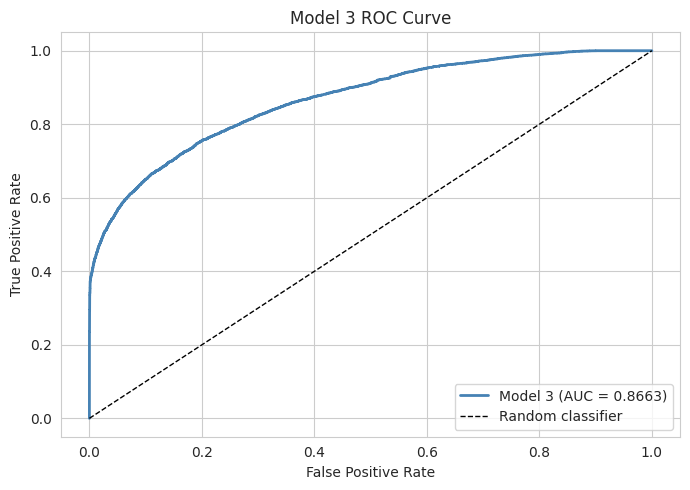

Model 3 ROC-AUC: 0.8663


In [25]:
fpr_m3, tpr_m3, thresholds = roc_curve(y_test, y_proba_m3)
auc_m3 = roc_auc_score(y_test, y_proba_m3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3, tpr_m3, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m3:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m3:.4f}")

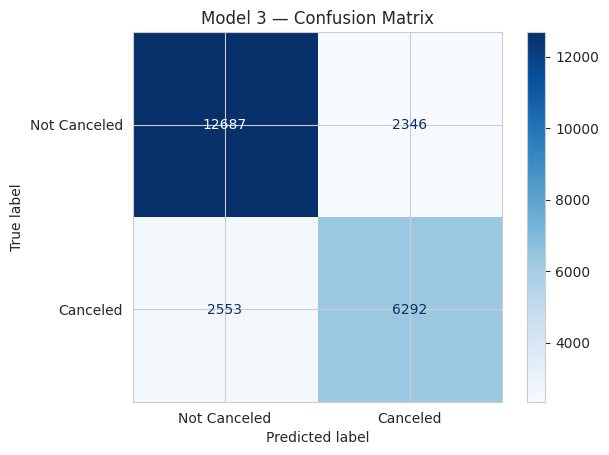

In [22]:
cm3 = confusion_matrix(y_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['Not Canceled', 'Canceled'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.show()

The new model using cross validation is stronger, with about a 33% decrease in false negatives, which is what we are looking to decrease

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---

After a lengthy analysis, I suggest that we institute a model using cross-validated data. We are trying to predict which bookings are likely to cancel, allowing us to overbook on that night and maximize profit. In our model, we are looking to maximize accuracy while minziming false negatives, where we predict a room is not going to cancel but ends up cancelling. Our most accurate model that also minimizes false negatives is our final model, and that is what I suggest we implement